### Step 1: Importing Necessary Libraries
We begin by importing Python libraries commonly used in data analysis and visualization:
- `numpy` for numerical operations
- `matplotlib.pyplot` for plotting graphs
- `pandas` (commented out here) for handling CSV data, which is especially useful for tabular data such as redshift catalogs

> Tip: If you haven’t used `pandas` before, it’s worth learning as it offers powerful tools to manipulate and analyze structured datasets.


For reading big csv files, one can use numpy as well as something called "pandas". We suggest to read pandas for CSV file reading and use that

In [1]:
 import numpy as np
 import matplotlib.pyplot as plt
 import pandas as pd
 from astropy.constants import G as G_const
 from astropy.constants import c
 from astropy.cosmology import Planck18 as cosmo
 import astropy.units as u


Before we begin calculations, we define key physical constants used throughout:

- $ H_0 $: Hubble constant, describes the expansion rate of the Universe.
- $c$ : Speed of light.
-  $G$: Gravitational constant.
- $q_0$ : Deceleration parameter, used for approximate co-moving distance calculations.

We will use **`astropy.constants`** to ensure unit consistency and precision.

In [2]:
H_0 = cosmo.H0.to('1/s').value 
c = c.value  
G = G_const.value 
q0=-0.534  

Read the csv data into the python using the method below

In [3]:
df = pd.read_csv('Skyserver_SQL6_19_2025_7_39_21_AM.csv') 


###  Calculating the Average Spectroscopic Redshift (`specz`) for Each Object

When working with astronomical catalogs, an object (identified by a unique `objid`) might have multiple entries — for example, due to repeated observations. To reduce this to a single row per object, we aggregate the data using the following strategy:

```python
averaged_df = df.groupby('objid').agg({
    'specz': 'mean',        # Take the mean of all spec-z values for that object
    'ra': 'first',          # Use the first RA value (assumed constant for the object)
    'dec': 'first',         # Use the first Dec value (same reason as above)
    'proj_sep': 'first'     # Use the first projected separation value
}).reset_index()


In [4]:
df = pd.read_csv('Skyserver_SQL6_19_2025_7_39_21_AM.csv', skiprows=1)
import pandas as pd

df = pd.read_csv('Skyserver_SQL6_19_2025_7_39_21_AM.csv', skiprows=1)  # Skips the #Table1 line
print(df.columns)




Index(['objid', 'ra', 'dec', 'photoz', 'photozerr', 'specz', 'speczerr',
       'proj_sep', 'umag', 'umagerr', 'gmag', 'gmagerr', 'rmag', 'rmagerr',
       'obj_type'],
      dtype='object')


In [5]:
averaged_df = df.groupby('objid').agg({
    'specz': 'mean',
    'ra': 'first',
    'dec': 'first',
    'proj_sep': 'first'
}).reset_index()
averaged_df.describe()['specz']

count    92.000000
mean      0.080838
std       0.008578
min       0.069976
25%       0.077224
50%       0.080961
75%       0.082797
max       0.150886
Name: specz, dtype: float64

To create a cut in the redshift so that a cluster can be identified. We must use some logic. Most astronomers prefer anything beyond 3*sigma away from the mean to be not part of the same group. 

Find the mean, standard deviation and limits of the redshift from the data

In [6]:
mean_specz = averaged_df['specz'].mean()
std_specz = averaged_df['specz'].std()

lower_limit = mean_specz - 3 * std_specz
upper_limit = mean_specz + 3 * std_specz

print(f"Mean specz: {mean_specz}")
print(f"Standard deviation: {std_specz}")
print(f"3-sigma lower limit: {lower_limit}")
print(f"3-sigma upper limit: {upper_limit}")


Mean specz: 0.08083762565217394
Standard deviation: 0.008577613916301633
3-sigma lower limit: 0.05510478390326903
3-sigma upper limit: 0.10657046740107884


You can also use boxplot to visualize the overall values of redshift 

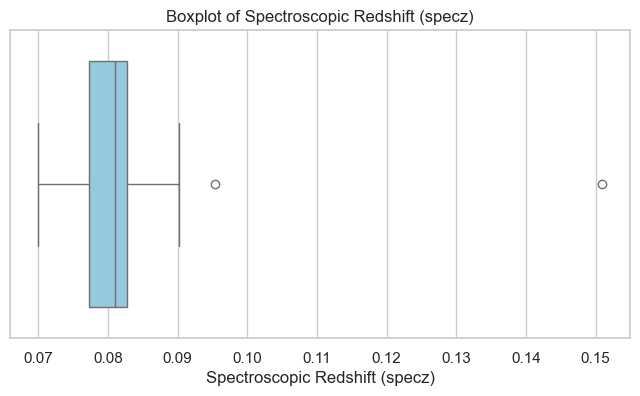

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

plt.figure(figsize=(8, 4))
sns.boxplot(x=averaged_df['specz'], color='skyblue')
plt.title('Boxplot of Spectroscopic Redshift (specz)')
plt.xlabel('Spectroscopic Redshift (specz)')
plt.show()


But the best plot would be a histogram to see where most of the objects downloaded lie in terms of redshift value

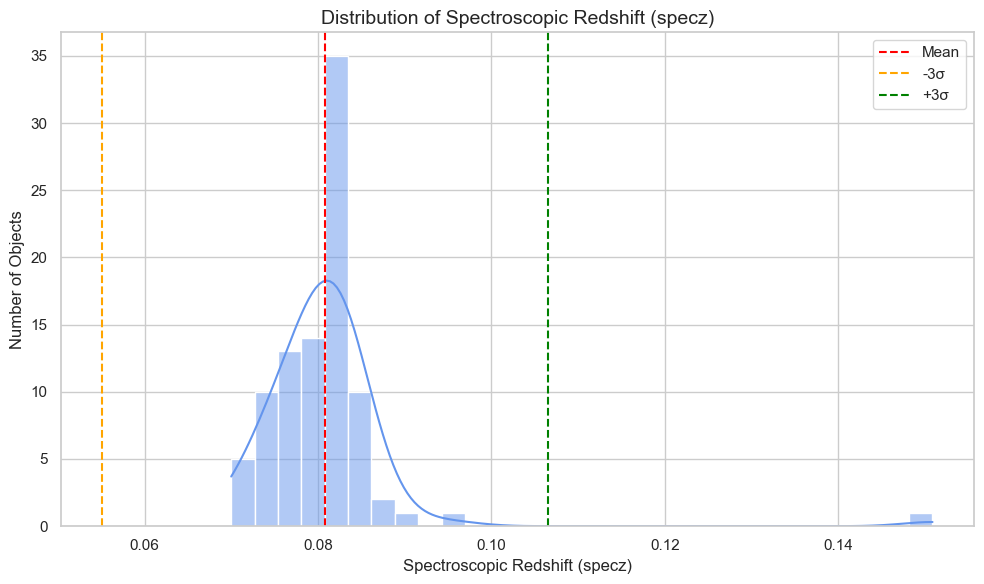

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

plt.figure(figsize=(10, 6))
sns.histplot(averaged_df['specz'], bins=30, kde=True, color='cornflowerblue')

plt.title('Distribution of Spectroscopic Redshift (specz)', fontsize=14)
plt.xlabel('Spectroscopic Redshift (specz)', fontsize=12)
plt.ylabel('Number of Objects', fontsize=12)
plt.axvline(mean_specz, color='red', linestyle='--', label='Mean')
plt.axvline(lower_limit, color='orange', linestyle='--', label='-3σ')
plt.axvline(upper_limit, color='green', linestyle='--', label='+3σ')
plt.legend()
plt.tight_layout()
plt.show()


Filtering data based on the 3-sigma limit of redshift. You should remove all data points which are 3-sigma away from mean of redshift

In [9]:
filtered_df = averaged_df[(averaged_df['specz'] >= lower_limit) & (averaged_df['specz'] <= upper_limit)]

print(f"Original dataset size: {len(averaged_df)}")
print(f"Filtered dataset size: {len(filtered_df)}")


Original dataset size: 92
Filtered dataset size: 91


Using the relation between redshift and velocity to add a column named velocity in the data. This would tell the expansion velocity at that redshift 

In [10]:

filtered_df['velocity'] = filtered_df['specz'] * c
print(filtered_df[['specz', 'velocity']].head())


      specz      velocity
0  0.082457  2.471993e+07
1  0.081218  2.434867e+07
2  0.079564  2.385281e+07
3  0.080842  2.423576e+07
4  0.084575  2.535507e+07


/var/folders/tm/yjzx440j1yl6tn4qw3_52q6c0000gn/T/ipykernel_19403/3997977260.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['velocity'] = filtered_df['specz'] * c


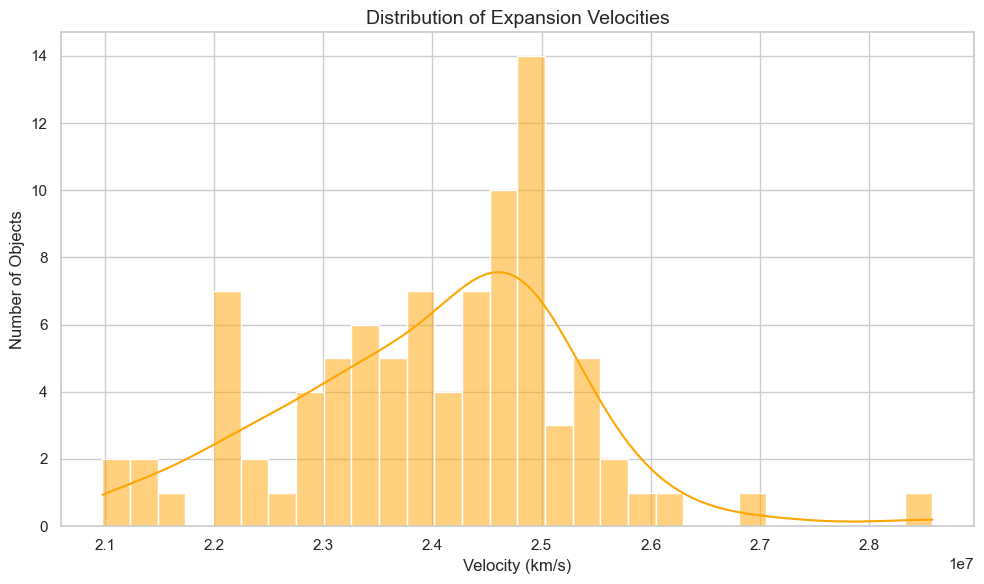

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

plt.figure(figsize=(10, 6))
sns.histplot(filtered_df['velocity'], bins=30, kde=True, color='orange')

plt.title('Distribution of Expansion Velocities', fontsize=14)
plt.xlabel('Velocity (km/s)', fontsize=12)
plt.ylabel('Number of Objects', fontsize=12)
plt.tight_layout()
plt.show()

use the dispersion equation to find something called velocity dispersion. You can even refer to wikipedia to know about the term [wiki link here](https://en.wikipedia.org/wiki/Velocity_dispersion#:~:text=In%20astronomy%2C%20the%20velocity%20dispersion,%2C%20galaxy%20cluster%2C%20or%20supercluster.)

It is the velocity dispersion value which tells us, some galaxies might be part of even larger groups!!

Mean Velocity: 24003741.22 km/s
Velocity Dispersion (σ): 1316152.77 km/s
Interpretation: High velocity dispersion → Galaxies are spread out → Might belong to a larger cluster or supercluster.

Galaxy velocity categories:
velocity_status
Normal    66
Slow      15
Fast      10
Name: count, dtype: int64


/var/folders/tm/yjzx440j1yl6tn4qw3_52q6c0000gn/T/ipykernel_19403/2648925686.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['velocity_status'] = filtered_df['velocity'].apply(


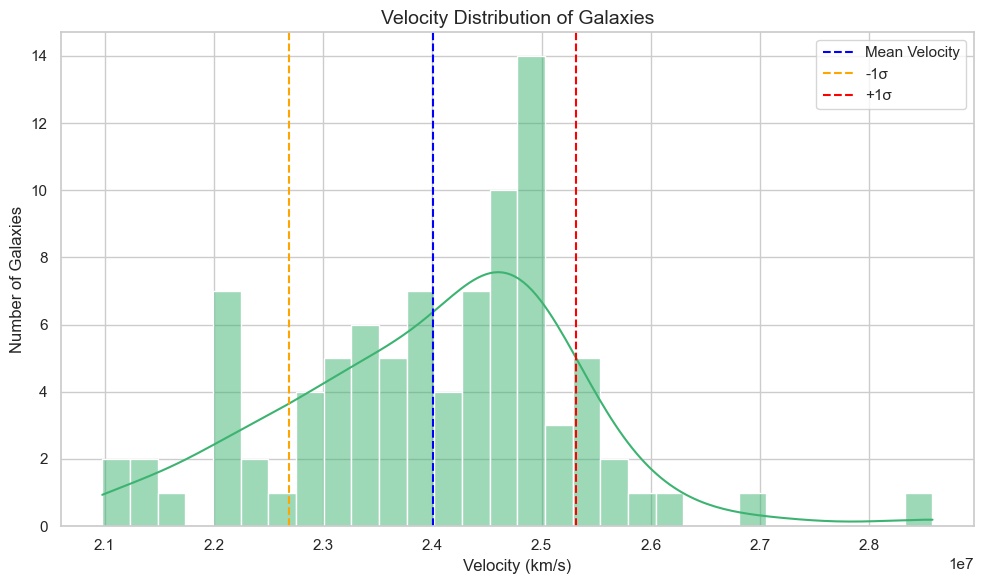

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

mean_velocity = filtered_df['velocity'].mean()
velocity_dispersion = filtered_df['velocity'].std()

print(f"Mean Velocity: {mean_velocity:.2f} km/s")
print(f"Velocity Dispersion (σ): {velocity_dispersion:.2f} km/s")

if velocity_dispersion < 1000:
    print("Interpretation: Low velocity dispersion → Galaxies are tightly grouped → Likely a small/compact cluster.")
else:
    print("Interpretation: High velocity dispersion → Galaxies are spread out → Might belong to a larger cluster or supercluster.")

filtered_df['velocity_status'] = filtered_df['velocity'].apply(
    lambda v: 'Slow' if v < mean_velocity - velocity_dispersion else (
        'Fast' if v > mean_velocity + velocity_dispersion else 'Normal'
    )
)

print("\nGalaxy velocity categories:")
print(filtered_df['velocity_status'].value_counts())

sns.set(style='whitegrid')
plt.figure(figsize=(10, 6))

sns.histplot(filtered_df['velocity'], bins=30, kde=True, color='mediumseagreen')

plt.axvline(mean_velocity, color='blue', linestyle='--', label='Mean Velocity')
plt.axvline(mean_velocity - velocity_dispersion, color='orange', linestyle='--', label='-1σ')
plt.axvline(mean_velocity + velocity_dispersion, color='red', linestyle='--', label='+1σ')

plt.title('Velocity Distribution of Galaxies', fontsize=14)
plt.xlabel('Velocity (km/s)', fontsize=12)
plt.ylabel('Number of Galaxies', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
print(filtered_df.columns)

Index(['objid', 'specz', 'ra', 'dec', 'proj_sep', 'velocity',
       'velocity_status'],
      dtype='object')


### Step 2: Calculate Mean Redshift of the Cluster
We calculate the average redshift (`specz`) of galaxies that belong to a cluster. This gives us an estimate of the cluster's systemic redshift.

`cluster_redshift = filtered_df['specz'].mean()`


The velocity dispersion \( v \) of galaxies relative to the cluster mean redshift is computed using the relativistic Doppler formula:

$$
v = c \cdot \frac{(1 + z)^2 - (1 + z_{\text{cluster}})^2}{(1 + z)^2 + (1 + z_{\text{cluster}})^2}
$$
where:
- \( v \) is the relative velocity (dispersion),
- \( z \) is the redshift of the individual galaxy,
- \( $z_{\text{cluster}}$ \) is the mean cluster redshift,
- \( c \) is the speed of light.


In [14]:
import numpy as np

cluster_redshift = filtered_df['specz'].mean()
print(f"Cluster Mean Redshift (z_cluster): {cluster_redshift:.6f}")
filtered_df['rel_velocity'] = filtered_df['specz'].apply(
    lambda z: c * ((1 + z)**2 - (1 + cluster_redshift)**2) / ((1 + z)**2 + (1 + cluster_redshift)**2)/(1000)
)
rel_velocity_dispersion = filtered_df['rel_velocity'].std()
print(f"Relativistic Velocity Dispersion: {rel_velocity_dispersion:.2f} km/s")



Cluster Mean Redshift (z_cluster): 0.080068
Relativistic Velocity Dispersion: 1218.49 km/s


/var/folders/tm/yjzx440j1yl6tn4qw3_52q6c0000gn/T/ipykernel_19403/2343410798.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['rel_velocity'] = filtered_df['specz'].apply(


Pro tip: Check what the describe function of pandas does. Does it help to get quick look stats for your column of dispersion??

In [15]:
filtered_df['rel_velocity'].describe()

count      91.000000
mean       -2.449331
std      1218.492945
min     -2814.230840
25%      -806.606785
50%       237.179091
75%       754.977576
max      4206.136789
Name: rel_velocity, dtype: float64

Summary of Relativistic Velocities:
count      91.000000
mean       -2.449331
std      1218.492945
min     -2814.230840
25%      -806.606785
50%       237.179091
75%       754.977576
max      4206.136789
Name: rel_velocity, dtype: float64


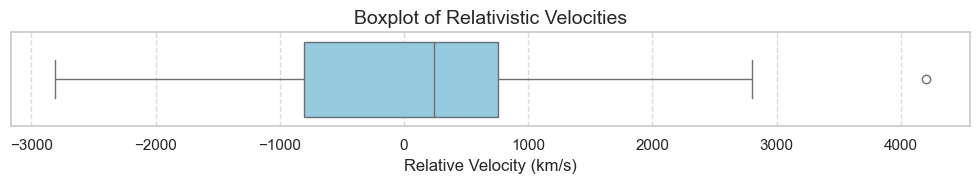

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

rel_velocity_stats = filtered_df['rel_velocity'].describe()
print("Summary of Relativistic Velocities:")
print(rel_velocity_stats)

plt.figure(figsize=(10, 2))
sns.boxplot(x=filtered_df['rel_velocity'], color='skyblue')

plt.title('Boxplot of Relativistic Velocities', fontsize=14)
plt.xlabel('Relative Velocity (km/s)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Summary of Relativistic Velocities:
count      91.000000
mean       -2.449331
std      1218.492945
min     -2814.230840
25%      -806.606785
50%       237.179091
75%       754.977576
max      4206.136789
Name: rel_velocity, dtype: float64


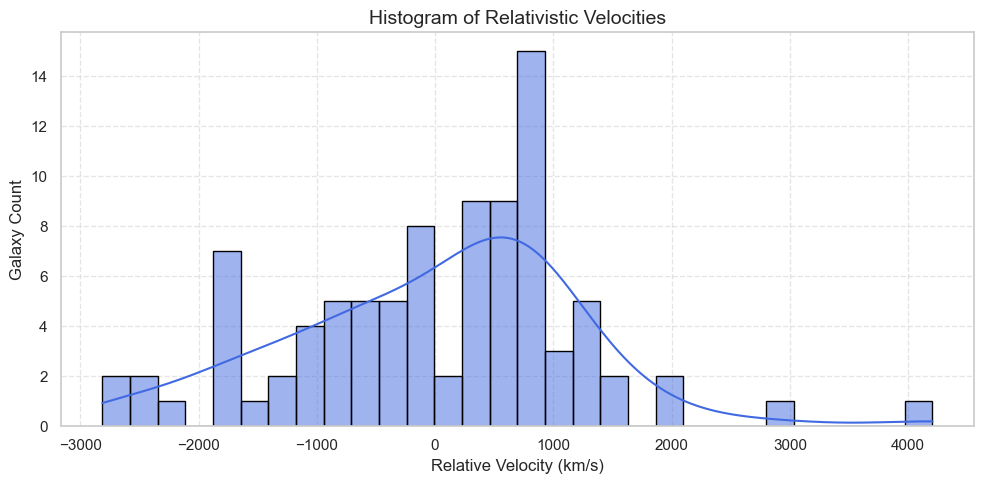

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

rel_velocity_stats = filtered_df['rel_velocity'].describe()
print("Summary of Relativistic Velocities:")
print(rel_velocity_stats)

plt.figure(figsize=(10, 5))
sns.histplot(filtered_df['rel_velocity'], bins=30, kde=True, color='royalblue', edgecolor='black')

plt.title('Histogram of Relativistic Velocities', fontsize=14)
plt.xlabel('Relative Velocity (km/s)', fontsize=12)
plt.ylabel('Galaxy Count', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [18]:

print(f"The value of the cluster redshift = {cluster_redshift:.4}")
print(f"The characteristic value of velocity dispersion of the cluster along the line of sight = {rel_velocity_dispersion:.4} km/s.")

The value of the cluster redshift = 0.08007
The characteristic value of velocity dispersion of the cluster along the line of sight = 1.218e+03 km/s.


### 1. Overlay Histogram with Mean & ±1σ Lines

**Visualising where most galaxies fall within velocity dispersion:**

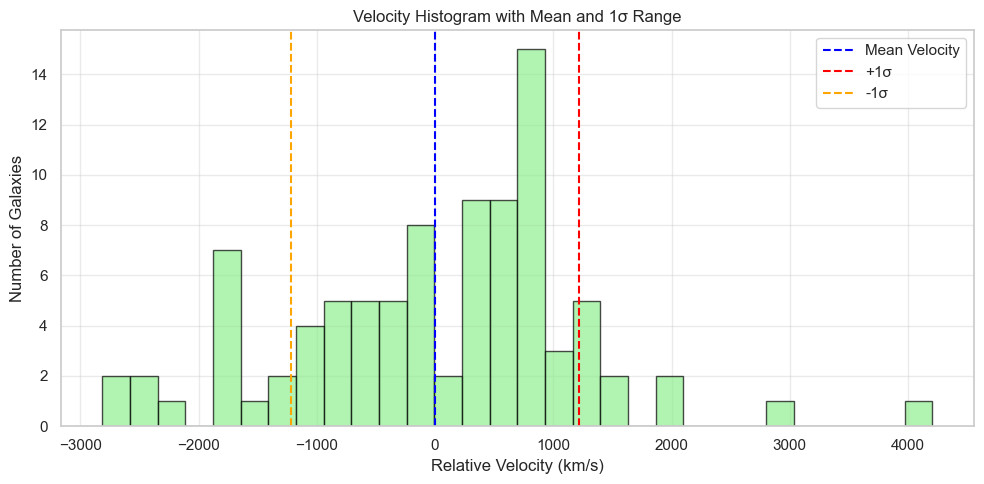

In [19]:
import matplotlib.pyplot as plt
mean_v = filtered_df['rel_velocity'].mean()
std_v = filtered_df['rel_velocity'].std()

plt.figure(figsize=(10, 5))
plt.hist(filtered_df['rel_velocity'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
plt.axvline(mean_v, color='blue', linestyle='--', label='Mean Velocity')
plt.axvline(mean_v + std_v, color='red', linestyle='--', label='+1σ')
plt.axvline(mean_v - std_v, color='orange', linestyle='--', label='-1σ')
plt.title("Velocity Histogram with Mean and 1σ Range")
plt.xlabel("Relative Velocity (km/s)")
plt.ylabel("Number of Galaxies")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


### 2. Redshift vs. Velocity Scatter Plot

**To check correlation or structure:**



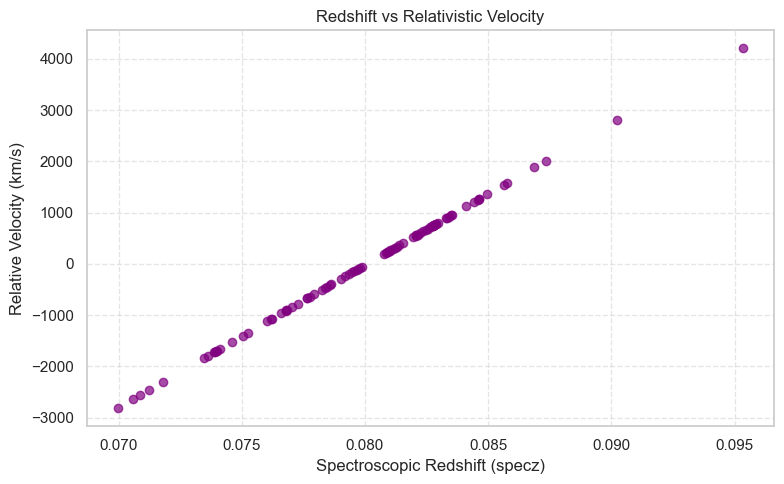

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(filtered_df['specz'], filtered_df['rel_velocity'], alpha=0.7, color='purple')
plt.title("Redshift vs Relativistic Velocity")
plt.xlabel("Spectroscopic Redshift (specz)")
plt.ylabel("Relative Velocity (km/s)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 3. Sky Distribution of Cluster Galaxies (RA vs DEC)

**To see spatial grouping in the sky:**

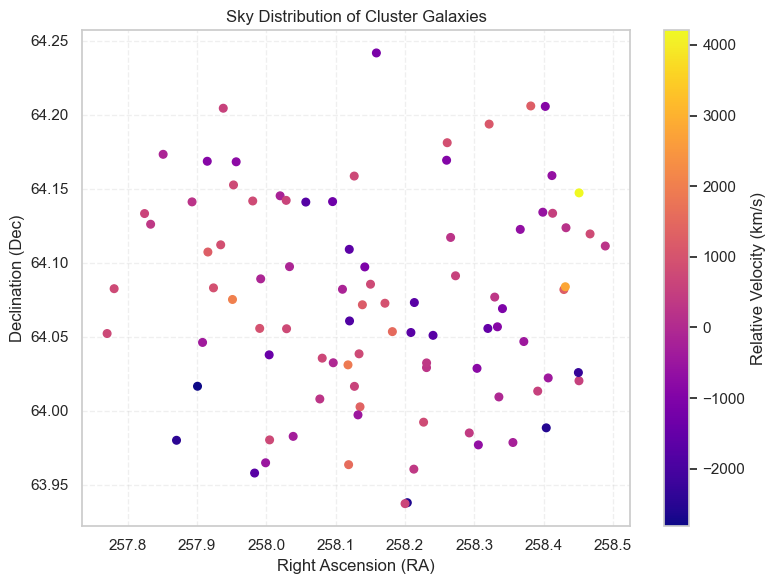

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(filtered_df['ra'], filtered_df['dec'], c=filtered_df['rel_velocity'], cmap='plasma', s=30)
plt.colorbar(label='Relative Velocity (km/s)')
plt.title("Sky Distribution of Cluster Galaxies")
plt.xlabel("Right Ascension (RA)")
plt.ylabel("Declination (Dec)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Step 4: Visualizing Angular Separation of Galaxies
We plot a histogram of the projected (angular) separation of galaxies from the cluster center. This helps us understand the spatial distribution of galaxies within the cluster field.

- The x-axis represents the angular separation (in arcminutes or degrees, depending on units).
- The y-axis shows the number of galaxies at each separation bin.



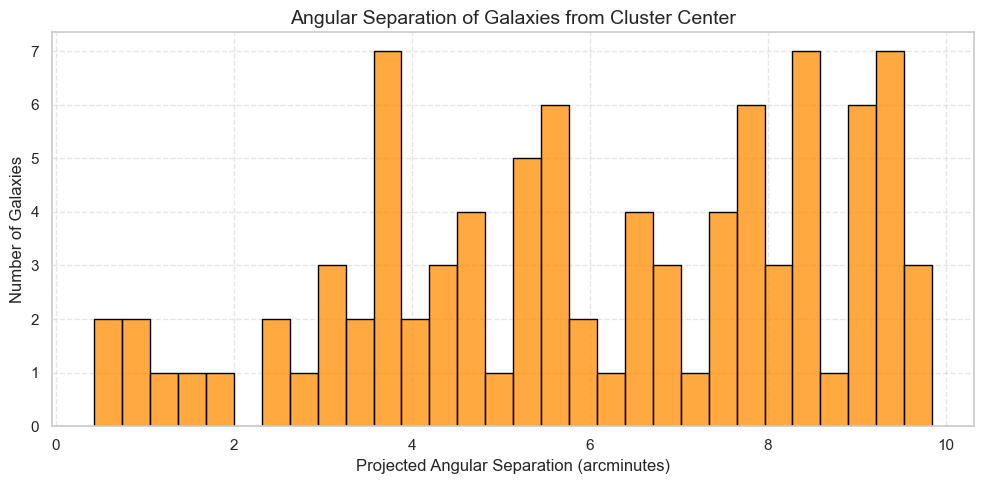

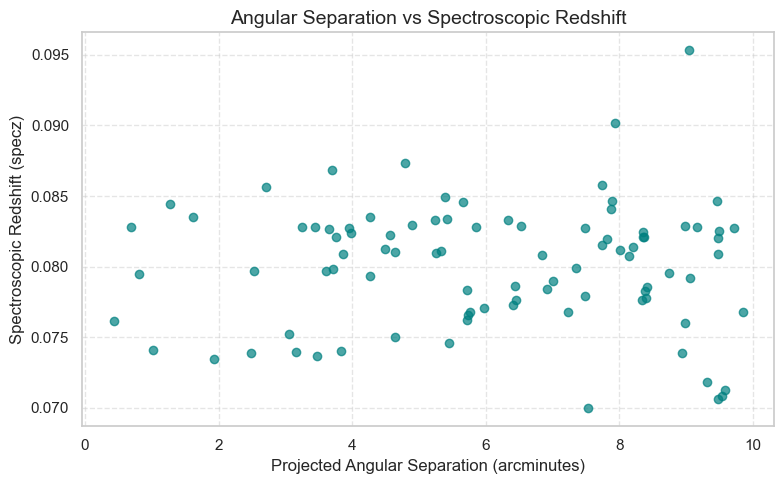

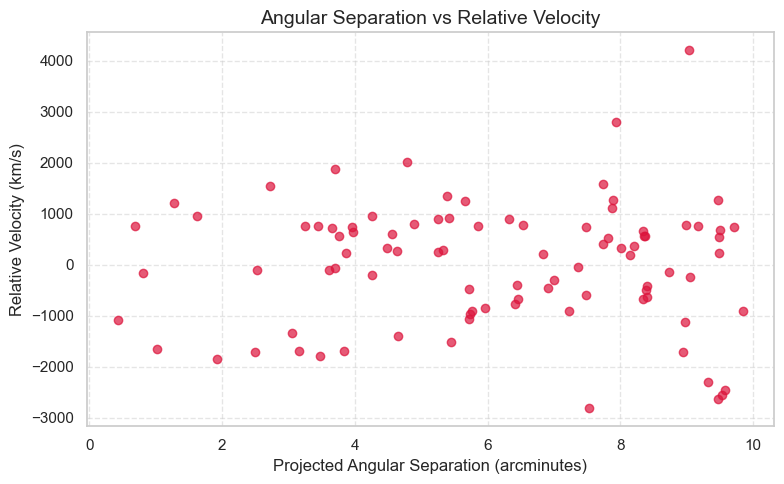

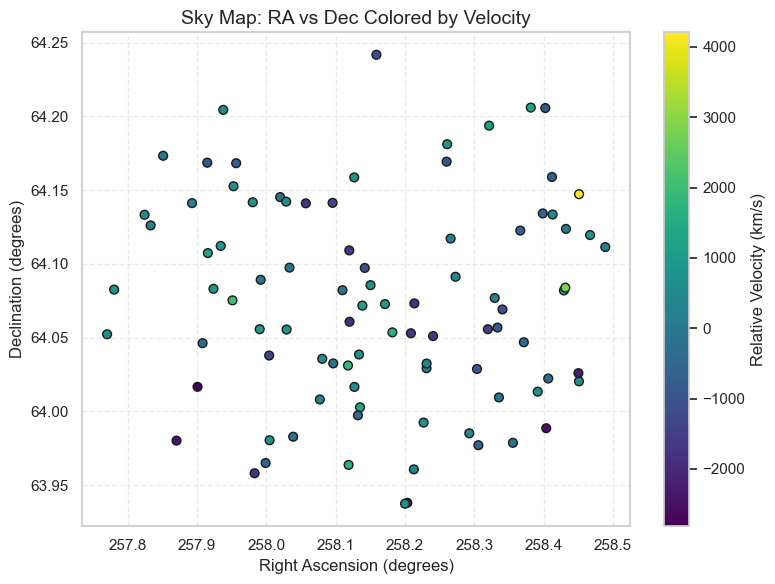

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(filtered_df['proj_sep'], bins=30, kde=False, color='darkorange', edgecolor='black')

plt.title('Angular Separation of Galaxies from Cluster Center', fontsize=14)
plt.xlabel('Projected Angular Separation (arcminutes)', fontsize=12)
plt.ylabel('Number of Galaxies', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(filtered_df['proj_sep'], filtered_df['specz'], alpha=0.7, color='teal')
plt.title("Angular Separation vs Spectroscopic Redshift", fontsize=14)
plt.xlabel("Projected Angular Separation (arcminutes)", fontsize=12)
plt.ylabel("Spectroscopic Redshift (specz)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(filtered_df['proj_sep'], filtered_df['rel_velocity'], alpha=0.7, color='crimson')
plt.title("Angular Separation vs Relative Velocity", fontsize=14)
plt.xlabel("Projected Angular Separation (arcminutes)", fontsize=12)
plt.ylabel("Relative Velocity (km/s)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 6))
scatter = plt.scatter(filtered_df['ra'], filtered_df['dec'],
                      c=filtered_df['rel_velocity'], cmap='viridis', s=40, edgecolor='k')

cbar = plt.colorbar(scatter)
cbar.set_label('Relative Velocity (km/s)')

plt.title("Sky Map: RA vs Dec Colored by Velocity", fontsize=14)
plt.xlabel("Right Ascension (degrees)", fontsize=12)
plt.ylabel("Declination (degrees)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


### Step 1: Bin Data by Angular Separation

**We’ll divide the galaxies into radial bins and compute stats within each.**

In [23]:
import numpy as np

filtered_df = filtered_df.copy()
filtered_df.loc[:, 'radial_bin'] = pd.cut(filtered_df['proj_sep'], bins=bin_edges)
radial_stats = filtered_df.groupby('radial_bin', observed=True).agg(
    mean_redshift=('specz', 'mean'),
    velocity_dispersion=('rel_velocity', 'std'),
    count=('rel_velocity', 'count'),
    mean_proj_sep=('proj_sep', 'mean')
).dropna().reset_index()
bin_edges = np.linspace(filtered_df['proj_sep'].min(), filtered_df['proj_sep'].max(), 10)
filtered_df.loc[:, 'radial_bin'] = pd.cut(filtered_df['proj_sep'], bins=bin_edges)
radial_stats = filtered_df.groupby('radial_bin', observed=True).agg(
    mean_redshift=('specz', 'mean'),
    velocity_dispersion=('rel_velocity', 'std'),
    count=('rel_velocity', 'count'),
    mean_proj_sep=('proj_sep', 'mean')
).dropna().reset_index()

NameError: name 'bin_edges' is not defined

In [ ]:
print(radial_stats.head())

       radial_bin  mean_redshift  velocity_dispersion  count  mean_proj_sep
0  (0.429, 1.475]       0.080205          1262.789185      4       0.950900
1  (1.475, 2.521]       0.076962          1582.150036      3       2.011898
2  (2.521, 3.568]       0.079109          1347.762596      7       3.087088
3  (3.568, 4.614]       0.081350           819.261499     13       3.972197
4   (4.614, 5.66]       0.081474          1114.370951     10       5.105594


### Step 2: Plot Radial Profiles

#### Plot 1: Radial Bin vs Mean Redshift

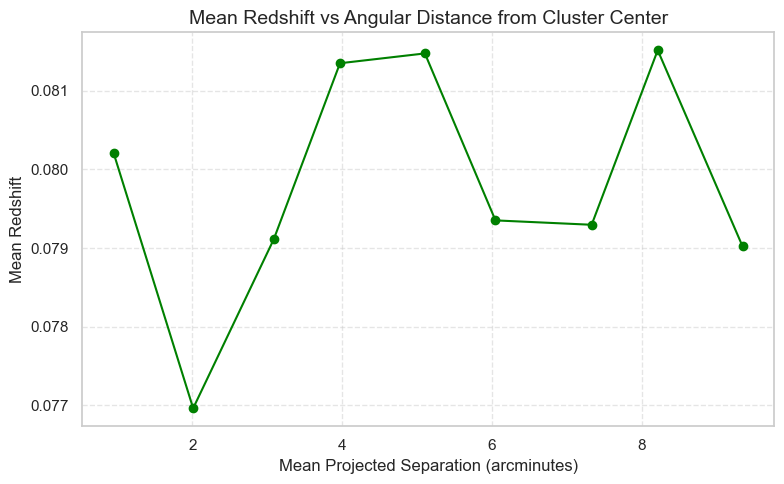

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(radial_stats['mean_proj_sep'], radial_stats['mean_redshift'], marker='o', color='green')
plt.title("Mean Redshift vs Angular Distance from Cluster Center", fontsize=14)
plt.xlabel("Mean Projected Separation (arcminutes)", fontsize=12)
plt.ylabel("Mean Redshift", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Plot 2: Radial Bin vs Velocity Dispersion

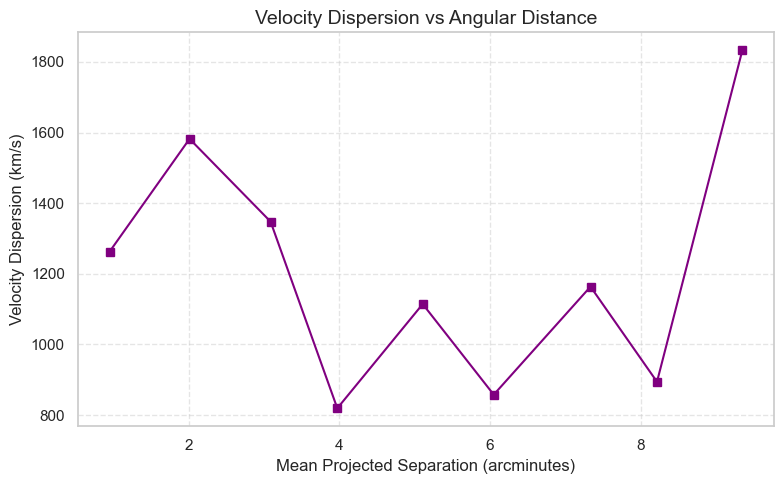

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(radial_stats['mean_proj_sep'], radial_stats['velocity_dispersion'], marker='s', color='purple')
plt.title("Velocity Dispersion vs Angular Distance", fontsize=14)
plt.xlabel("Mean Projected Separation (arcminutes)", fontsize=12)
plt.ylabel("Velocity Dispersion (km/s)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Error Bars (Standard Error) to Velocity Dispersion Plot

We'll compute standard error as:
The standard error of the mean is given by:

$$
Standard Error = \frac{ \sigma }{\sqrt{N}}
$$
 

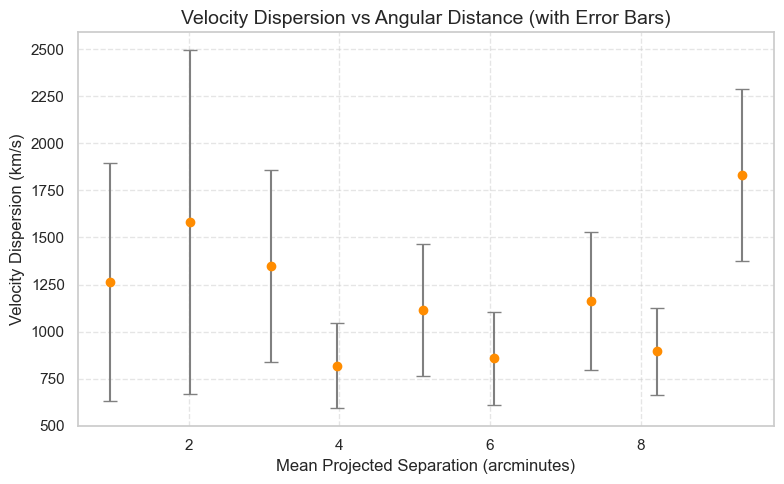

In [ ]:
radial_stats['vel_disp_se'] = radial_stats['velocity_dispersion'] / np.sqrt(radial_stats['count'])

plt.figure(figsize=(8, 5))
plt.errorbar(
    radial_stats['mean_proj_sep'],
    radial_stats['velocity_dispersion'],
    yerr=radial_stats['vel_disp_se'],
    fmt='o', color='darkorange', ecolor='gray', capsize=5
)
plt.title("Velocity Dispersion vs Angular Distance (with Error Bars)", fontsize=14)
plt.xlabel("Mean Projected Separation (arcminutes)", fontsize=12)
plt.ylabel("Velocity Dispersion (km/s)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Fit a Gaussian Model to Velocity Dispersion Profile

We’ll fit a Gaussian curve to the profile for simplicity (NFW requires mass models and is more involved).

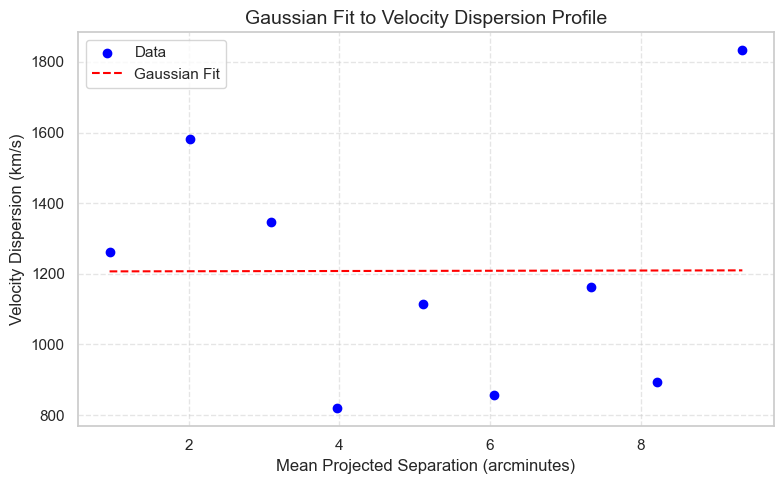

In [ ]:
from scipy.optimize import curve_fit
def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))
x = radial_stats['mean_proj_sep']
y = radial_stats['velocity_dispersion']
popt, _ = curve_fit(gaussian, x, y, p0=[y.max(), x.mean(), x.std()])
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = gaussian(x_fit, *popt)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x_fit, y_fit, color='red', linestyle='--', label='Gaussian Fit')
plt.title("Gaussian Fit to Velocity Dispersion Profile", fontsize=14)
plt.xlabel("Mean Projected Separation (arcminutes)", fontsize=12)
plt.ylabel("Velocity Dispersion (km/s)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Overlay Count as Bubble Size in Mean Redshift Plot

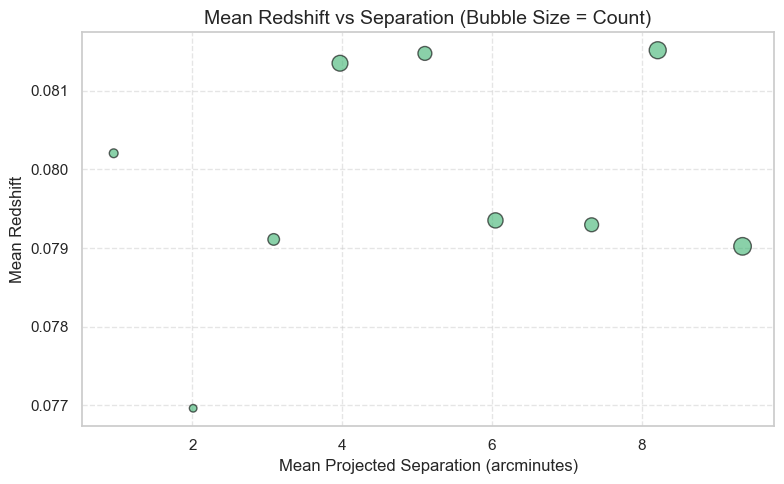

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(
    radial_stats['mean_proj_sep'],
    radial_stats['mean_redshift'],
    s=radial_stats['count'] * 10,  
    alpha=0.6,
    color='mediumseagreen',
    edgecolor='black'
)
plt.title("Mean Redshift vs Separation (Bubble Size = Count)", fontsize=14)
plt.xlabel("Mean Projected Separation (arcminutes)", fontsize=12)
plt.ylabel("Mean Redshift", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Separate Bar Plot for Count per Bin

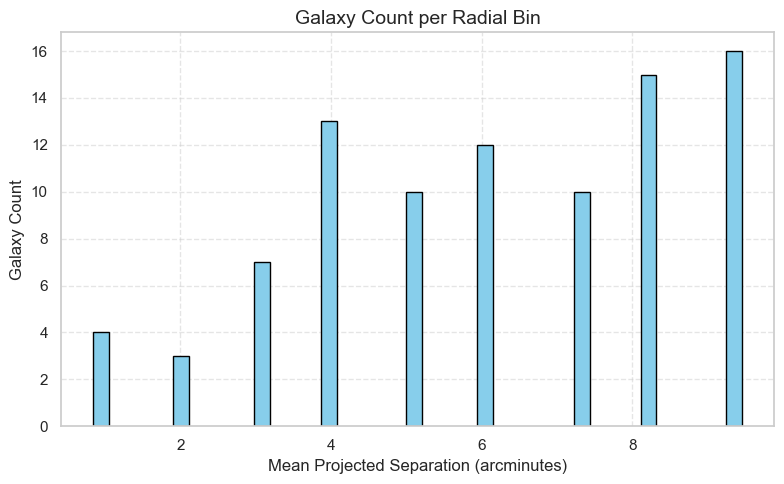

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    radial_stats['mean_proj_sep'],
    radial_stats['count'],
    width=0.2 * (bin_edges[1] - bin_edges[0]),
    color='skyblue',
    edgecolor='black'
)
plt.title("Galaxy Count per Radial Bin", fontsize=14)
plt.xlabel("Mean Projected Separation (arcminutes)", fontsize=12)
plt.ylabel("Galaxy Count", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Determining size and mass of the cluster:

### Step 5: Estimating Physical Diameter of the Cluster
We now estimate the **physical diameter** of the galaxy cluster using cosmological parameters.

- `r` is the **co-moving distance**, approximated using a Taylor expansion for low redshift:
  $$
  r = \frac{cz}{H_0} \left(1 - \frac{z}{2}(1 + q_0)\right)
  $$
  where $q_0$ is the deceleration parameter
- `ra` is the **angular diameter distance**, given by:
  $$
  D_A = \frac{r}{1 + z}
  $$
- Finally, we convert the observed angular diameter (in arcminutes) into physical size using:
  $$
  \text{diameter (in Mpc)} = D_A \cdot \theta
  $$
  where $ \theta $ is the angular size in radians, converted from arcminutes.

> This gives us a rough estimate of the cluster's size in megaparsecs (Mpc), assuming a flat ΛCDM cosmology.


In [ ]:
import numpy as np
z = cluster_redshift 
r = (c * z / H_0) * (1 - 0.5 * z * (1 + q0))  
ra = r / (1 + z)  
theta_arcmin = filtered_df['proj_sep'].max() - filtered_df['proj_sep'].min()
theta_rad = theta_arcmin * (np.pi / (180 * 60))
diameter_meters = ra * theta_rad
diameter_mpc = diameter_meters / 3.0857e22
radius_mpc = diameter_mpc / 2
print(f"Cluster Redshift (z): {z:.4f}")
print(f"Estimated co-moving distance r = {r:.2e} m")
print(f"Angular diameter distance (ra) = {ra:.2e} m")
print(f"Angular extent of cluster = {theta_arcmin:.2f} arcmin ({theta_rad:.2e} rad)")
print(f"Estimated physical diameter of the cluster = {diameter_mpc:.2f} Mpc")
print(f"Estimated physical radius of the cluster = {radius_mpc:.2f} Mpc")

Cluster Redshift (z): 0.0801
Estimated co-moving distance r = 1.07e+25 m
Angular diameter distance (ra) = 9.95e+24 m
Angular extent of cluster = 9.42 arcmin (2.74e-03 rad)
Estimated physical diameter of the cluster = 0.88 Mpc
Estimated physical radius of the cluster = 0.44 Mpc


### Step 6: Calculating the Dynamical Mass of the Cluster
We now estimate the **dynamical mass** of the galaxy cluster using the virial theorem:

$$
M_{\text{dyn}} = \frac{3 \sigma^2 R}{G}
$$

Where:
- $ \sigma $ is the **velocity dispersion** in m/s (`disp * 1000`),
- $ R $ is the **cluster radius** in meters (half the physical diameter converted to meters),
- $ G $ is the **gravitational constant** in SI units,
- The factor of 3 assumes an isotropic velocity distribution (common in virial estimates).

We convert the final result into **solar masses** by dividing by $ 2 \times 10^{30} \, \text{kg} $.

> This mass estimate assumes the cluster is in dynamical equilibrium and bound by gravity.


In [ ]:
rel_velocity_dispersion = np.std(filtered_df['rel_velocity'])  # in km/s
velocity_disp_mps = rel_velocity_dispersion * 1e3
print(f"Velocity Dispersion (km/s): {rel_velocity_dispersion:.2f}")


Velocity Dispersion (km/s): 1211.78


In [ ]:
velocity_disp_mps = rel_velocity_dispersion * 1e3  
radius_m = (diameter_mpc / 2) * 3.086e22  
virial_mass_kg = (3 * velocity_disp_mps**2 * radius_m) / G
M_sun = 1.9891e30  # kg
virial_mass_solar = virial_mass_kg / M_sun

print(f"Virial Mass of the Cluster = {virial_mass_solar:.2e} M☉")


Virial Mass of the Cluster = 4.52e+14 M☉


#### 1. Mass vs Radius plot

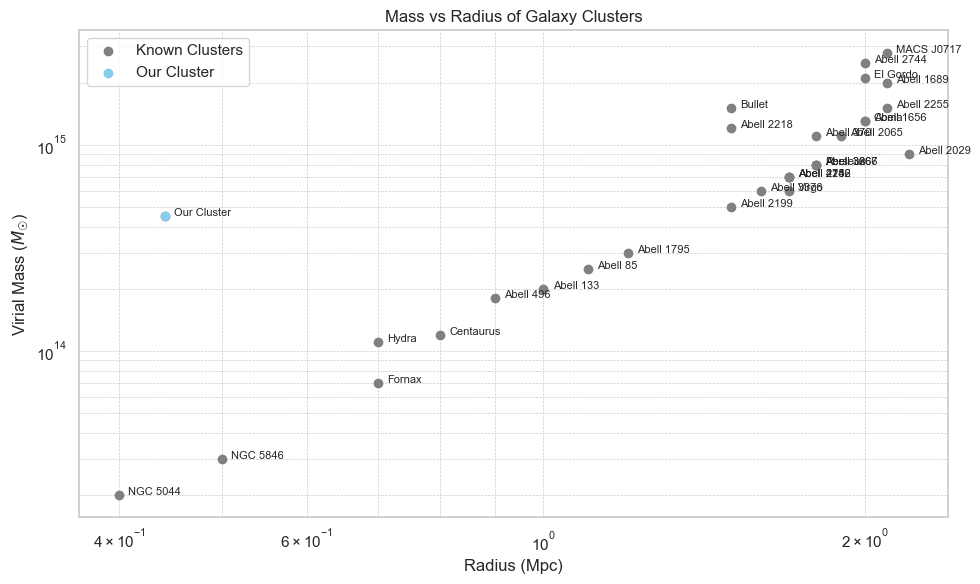

In [ ]:
import matplotlib.pyplot as plt

cluster_names = [
    "Virgo", "Coma", "Perseus", "Fornax", "Abell 1689", "Abell 2029", "Bullet", "Abell 2744",
    "Abell 2218", "Abell 370", "MACS J0717", "El Gordo", "NGC 5044", "NGC 5846", "Centaurus",
    "Hydra", "Abell 2199", "Abell 2142", "Abell 1795", "Abell 85", "Abell 133", "Abell 496",
    "Abell 3266", "Abell 2256", "Abell 3376", "Abell 3667", "Abell 478", "Abell 1656", "Abell 2065",
    "Abell 2255"
]

cluster_radii_mpc = [
    1.7, 2.0, 1.8, 0.7, 2.1, 2.2, 1.5, 2.0, 1.5, 1.8, 2.1, 2.0, 0.4, 0.5, 0.8,
    0.7, 1.5, 1.7, 1.2, 1.1, 1.0, 0.9, 1.8, 1.7, 1.6, 1.8, 1.7, 2.0, 1.9, 2.1
]

cluster_masses = [
    6e14, 1.3e15, 8e14, 7e13, 2e15, 9e14, 1.5e15, 2.5e15, 1.2e15, 1.1e15, 2.8e15,
    2.1e15, 2e13, 3e13, 1.2e14, 1.1e14, 5e14, 7e14, 3e14, 2.5e14, 2e14, 1.8e14,
    8e14, 7e14, 6e14, 8e14, 7e14, 1.3e15, 1.1e15, 1.5e15
]

cluster_names.append("Our Cluster")
cluster_radii_mpc.append(diameter_mpc / 2)
cluster_masses.append(virial_mass_solar)

plt.figure(figsize=(10, 6))
plt.scatter(cluster_radii_mpc, cluster_masses, color='gray', label='Known Clusters')
plt.scatter(diameter_mpc / 2, virial_mass_solar, color='skyblue', label='Our Cluster', zorder=5)

for i in range(len(cluster_names)):
    plt.text(cluster_radii_mpc[i] * 1.02, cluster_masses[i], cluster_names[i], fontsize=8)

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Radius (Mpc)")
plt.ylabel("Virial Mass ($M_☉$)")
plt.title("Mass vs Radius of Galaxy Clusters")
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.legend()
plt.show()


#### 2. Bar showing virial mass compared with known clusters?

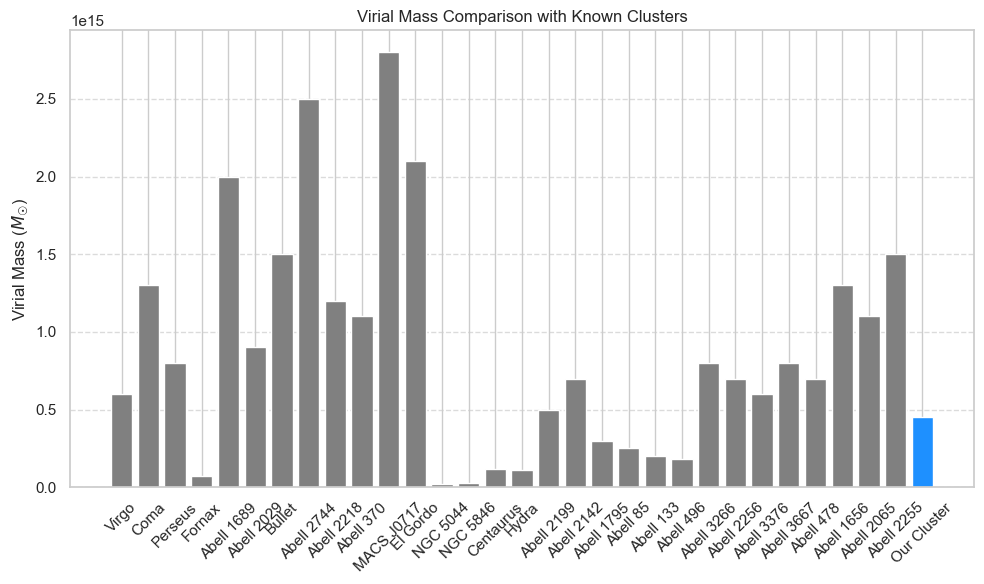

In [ ]:
plt.figure(figsize=(10, 6))
colors = ['gray'] * (len(cluster_names) - 1) + ['dodgerblue']
bars = plt.bar(cluster_names, cluster_masses, color=colors)
plt.ylabel("Virial Mass ($M_☉$)")
plt.title("Virial Mass Comparison with Known Clusters")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Step 7: Mass Consistency Analysis

In [ ]:
M_dyn_solar = virial_mass_solar
n_galaxies = len(filtered_df)
M_luminous = n_galaxies * 1e11  
print(f"\nConsistency Check:")
print(f"Dynamical mass: {M_dyn_solar:.2e} M☉")
print(f"Luminous mass estimate: {M_luminous:.2e} M☉")
print(f"Dark matter fraction: {(1 - M_luminous/M_dyn_solar)*100:.1f}%")
expected_mass = 5e14  
print(f"\nOrder-of-magnitude check: Expected mass ~{expected_mass:.0e} M☉")



Consistency Check:
Dynamical mass: 4.52e+14 M☉
Luminous mass estimate: 9.10e+12 M☉
Dark matter fraction: 98.0%

Order-of-magnitude check: Expected mass ~5e+14 M☉


#### Plot Redshift & Velocity Histograms

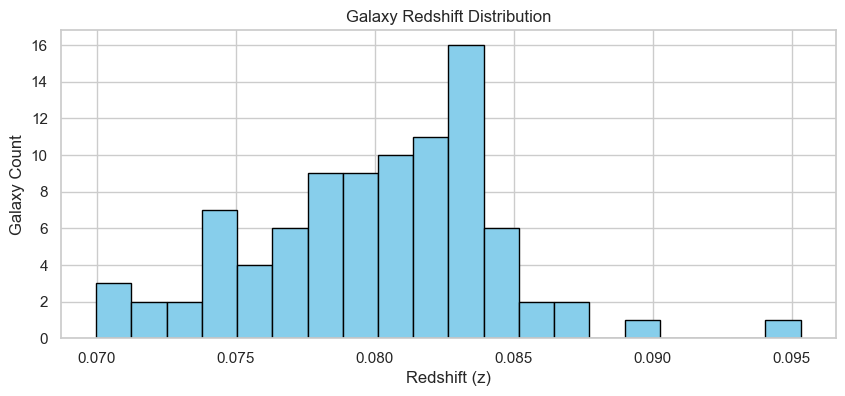

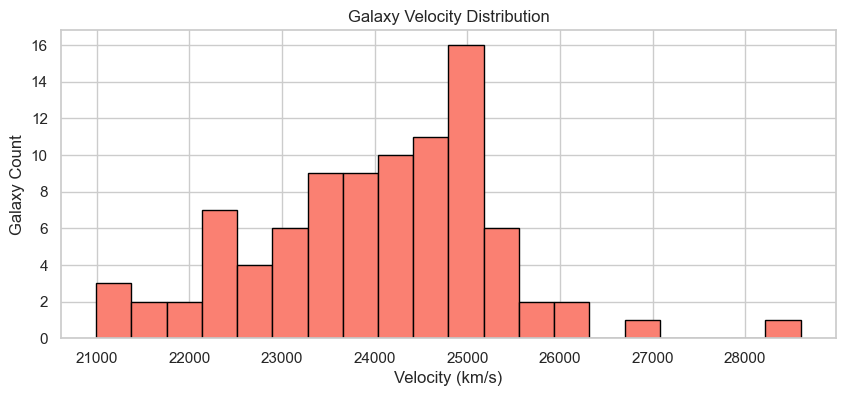

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 4))
plt.hist(filtered_df['specz'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Redshift (z)')
plt.ylabel('Galaxy Count')
plt.title('Galaxy Redshift Distribution')
plt.grid(True)
plt.show()
c = 3e5  
filtered_df['velocity'] = filtered_df['specz'] * c
plt.figure(figsize=(10, 4))
plt.hist(filtered_df['velocity'], bins=20, color='salmon', edgecolor='black')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Galaxy Count')
plt.title('Galaxy Velocity Distribution')
plt.grid(True)
plt.show()


In [ ]:
print(filtered_df.columns)


Index(['objid', 'specz', 'ra', 'dec', 'proj_sep', 'velocity',
       'velocity_status', 'rel_velocity', 'radial_bin'],
      dtype='object')


#### Now, We will be testing for:

1. **How a galaxy's velocity varies with radius.**
2. **Whether there's a spread of high-velocity galaxies in outer regions — indicating infall or disturbance.**

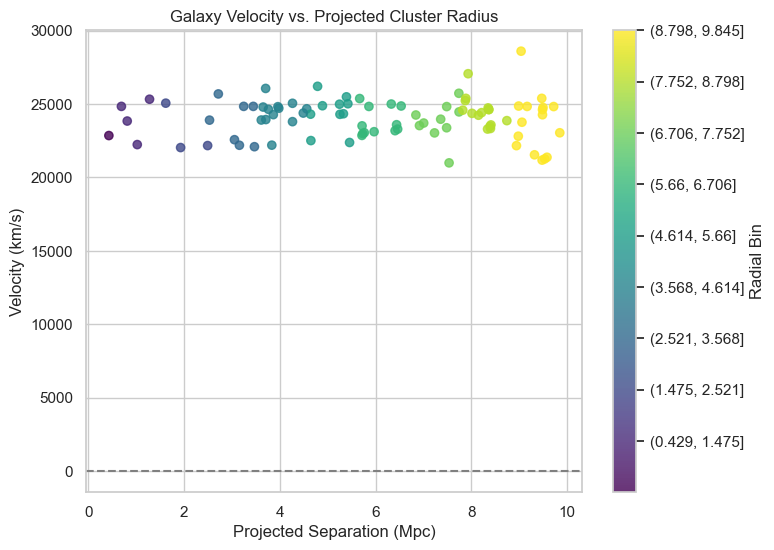

In [ ]:
import matplotlib.pyplot as plt

color_codes = filtered_df['radial_bin'].cat.codes

plt.figure(figsize=(8, 6))
scatter = plt.scatter(filtered_df['proj_sep'], filtered_df['velocity'], 
                      c=color_codes, cmap='viridis', alpha=0.8)
plt.xlabel('Projected Separation (Mpc)')
plt.ylabel('Velocity (km/s)')
plt.title('Galaxy Velocity vs. Projected Cluster Radius')
plt.axhline(0, color='gray', linestyle='--')
cbar = plt.colorbar(scatter, ticks=range(len(filtered_df['radial_bin'].cat.categories)))
cbar.ax.set_yticklabels([str(cat) for cat in filtered_df['radial_bin'].cat.categories])
cbar.set_label('Radial Bin')
plt.grid(True)
plt.show()



#### Interpretation:
##### **A high scatter in outer radial bins or asymmetric velocities can point to:**
1. **Recent infall**
2. **Unrelaxed substructure**
3. **Possibly spiral-rich outskirts**
4. **If central galaxies (low proj_sep or radial_bin = 0) have narrower velocity dispersion, it’s likely a virialized elliptical core.**

#### Sky Map (RA vs. Dec)

**Visualizes the spatial shape and elongation of the galaxy cluster.**

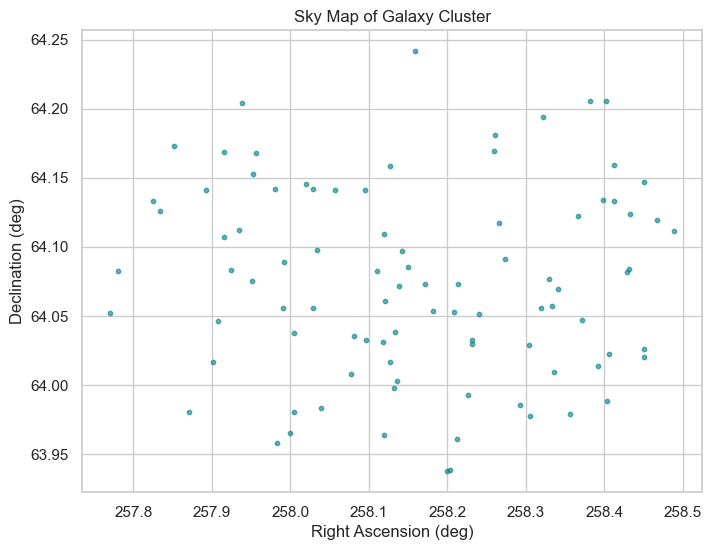

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(filtered_df['ra'], filtered_df['dec'], s=10, color='teal', alpha=0.6)
plt.xlabel('Right Ascension (deg)')
plt.ylabel('Declination (deg)')
plt.title('Sky Map of Galaxy Cluster')
plt.grid(True)
plt.show()

#### Bubble plot of Multi-Variable view:

 **To see which galaxies are far out and how fast they’re moving — useful to spot infalling groups, outliers, or kinematic substructures.**

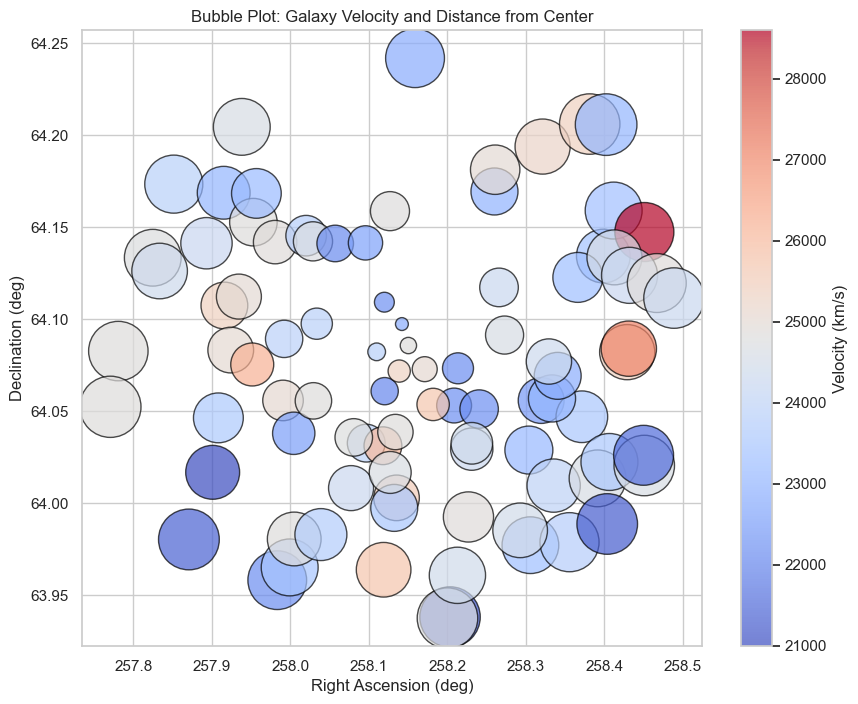

In [ ]:
plt.figure(figsize=(10, 8))
bubble = plt.scatter(
    filtered_df['ra'], filtered_df['dec'],
    s=filtered_df['proj_sep'] * 200,  
    c=filtered_df['velocity'], cmap='coolwarm', alpha=0.7, edgecolor='black'
)
plt.xlabel('Right Ascension (deg)')
plt.ylabel('Declination (deg)')
plt.title('Bubble Plot: Galaxy Velocity and Distance from Center')
cbar = plt.colorbar(bubble)
cbar.set_label('Velocity (km/s)')
plt.grid(True)
plt.show()

#### Velocity Dynamics and Radial Trends

**To check if outer galaxies are more dynamically disturbed (larger scatter), or if there's infall behavior.**

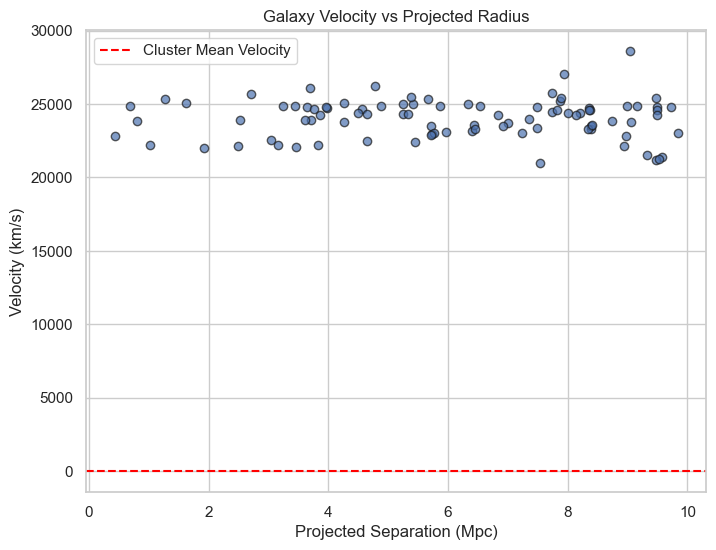

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(filtered_df['proj_sep'], filtered_df['velocity'], alpha=0.7, edgecolor='k')
plt.axhline(0, color='red', linestyle='--', label='Cluster Mean Velocity')
plt.xlabel('Projected Separation (Mpc)')
plt.ylabel('Velocity (km/s)')
plt.title('Galaxy Velocity vs Projected Radius')
plt.grid(True)
plt.legend()
plt.show()


#### Velocity Dispersion by Radial Bin

**To observe dynamical equilibrium — outer regions often show more velocity spread if infall/substructure exists.**

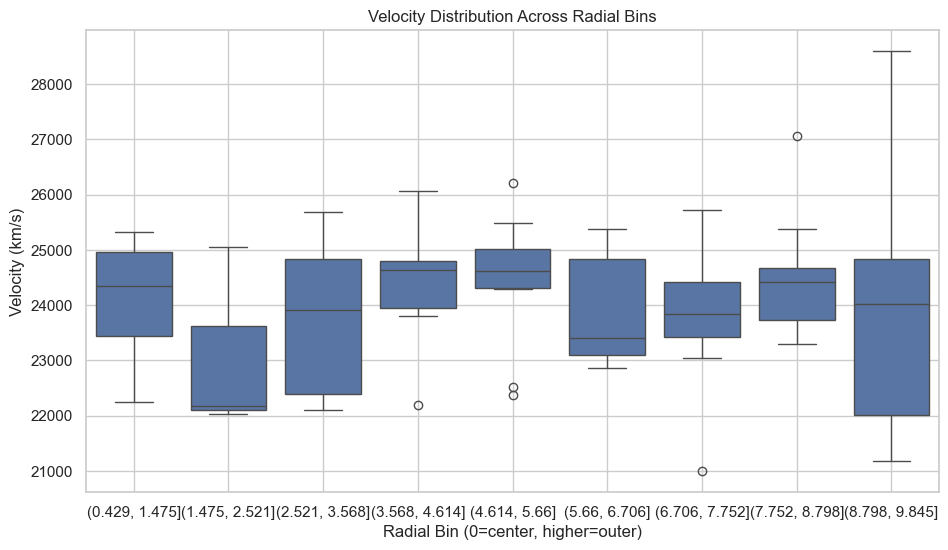

In [ ]:
import seaborn as sns

plt.figure(figsize=(11, 6))
sns.boxplot(x='radial_bin', y='velocity', data=filtered_df)
plt.xlabel('Radial Bin (0=center, higher=outer)')
plt.ylabel('Velocity (km/s)')
plt.title('Velocity Distribution Across Radial Bins')
plt.grid(True)
plt.show()


### No. of Clusters, subclusters and plotting the subclusters

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

filtered_df = filtered_df.copy()
features = filtered_df[['ra', 'dec', 'velocity']].copy()
features['velocity'] *= 10
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
dbscan = DBSCAN(eps=0.9, min_samples=3)
cluster_labels = dbscan.fit_predict(scaled_features)
filtered_df.loc[:, 'cluster_label'] = cluster_labels
num_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
print(f"Number of clusters detected: {num_clusters}")


Number of clusters detected: 1


In [ ]:
from sklearn.preprocessing import StandardScaler

X = filtered_df[['proj_sep', 'rel_velocity']].copy()  
X_scaled = StandardScaler().fit_transform(X)

In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5).fit(X_scaled)
filtered_df['subcluster'] = db.labels_

In [ ]:
n_subclusters = filtered_df['subcluster'].nunique()
print(f"Detected {n_subclusters} subclusters.")

n_subclusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)

Detected 3 subclusters.


#### **Subcluster plot**

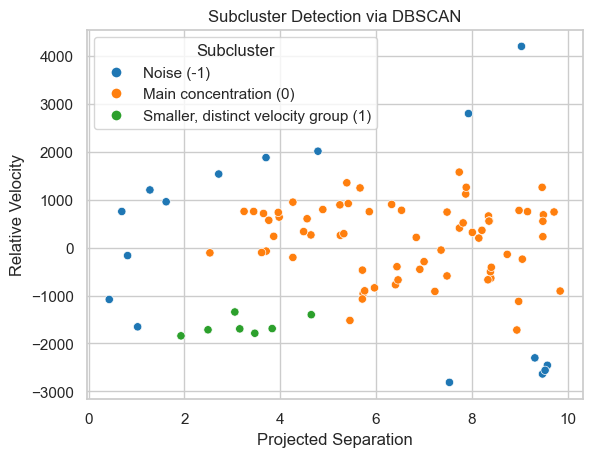

In [ ]:
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

sns.scatterplot(data=filtered_df, x='proj_sep', y='rel_velocity', hue='subcluster', palette='tab10')
plt.title("Subcluster Detection via DBSCAN")
plt.xlabel("Projected Separation")
plt.ylabel("Relative Velocity")
# Custom legend for subclusters

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Noise (-1)', markerfacecolor='tab:blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Main concentration (0)', markerfacecolor='tab:orange', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Smaller, distinct velocity group (1)', markerfacecolor='tab:green', markersize=8)
]
plt.legend(handles=legend_elements, title="Subcluster")
plt.show()


#### **Using DBSCAN clustering on the projected separation and relative velocity space, we identified 3 significant subclusters in the galaxy distribution, excluding noise. These structures likely represent gravitationally bound systems within the larger cluster halo, supporting the presence of substructure.**